### 1. Setup and Imports

In [1]:
from chromadb.config import Settings
from chromadb import Client
from langchain.vectorstores import Chroma
import chromadb

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from typing_extensions import List, TypedDict
from langgraph.graph import START, StateGraph

import os, re, json
import numpy as np
import pandas as pd
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# For evaluation metrics
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer
from bert_score import score as bert_score

date = datetime.today().strftime('%Y-%m-%d')

# Initialize Langsmith
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = "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"
os.environ["LANGSMITH_PROJECT"] = f"[{date}] VAA - RAG Evaluation"

# Initialize LLM and Embeddings
REASONING = True
llm = ChatOllama(model="deepseek-r1:8b", validate_model_on_init=True, temperature=0.6, reasoning=REASONING)
emb = OllamaEmbeddings(model="bge-m3:567m")

print("✓ Libraries and models initialized")

✓ Libraries and models initialized


### 2. Initialize Vector Store

In [2]:
SINGLE = True
collection_name = "polyu_eee_document" if not SINGLE else "vaa_documents"

client = Client(Settings())
client = chromadb.PersistentClient(path="../chroma_db")

vectorStore = Chroma(
    collection_name=collection_name, 
    client=client, 
    embedding_function=emb
)

print(f"✓ Vector store loaded: {collection_name}")
print(f"Total documents: {vectorStore._collection.count()}")

✓ Vector store loaded: vaa_documents
Total documents: 3953


/var/folders/cf/1j9rc9v11rzf5wxcjw3w_wsm0000gp/T/ipykernel_10296/2564586646.py:7: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorStore = Chroma(


### 3. Load RAG System from Existing Notebook

In [3]:
# Import the RAG-Fusion implementation
num_queries = 4

LLM_prompt = """
You are a professional academic advisor at The Hong Kong Polytechnic University. Please adhere to the following rules:
    1. Answer in the same language as the user query, e.g., English query, English answer.
    2. Avoid saying "may", "maybe", or anything similar; be affirmative, confident, and decisive in your answers.
    3. Avoid saying "based on the provided context", or anything similar; answer directly.
    4. Say no if you cannot answer the question; do not fabricate a factually false answer.
    5. Provide advice to the student if necessary.

Now, please use the following context to answer the student's question.
Remember to be nice and ask if there are any more enquiries.

*Context*:
----------
{context}
----------

*Student's Question*:
{question}

Helpful Answer:
"""
prompt = PromptTemplate.from_template(LLM_prompt)

RAG_FUSION_PROMPT = """
You are a helpful assistant that generates multiple search questions based on a single input query.

Provide {num_queries} search questions separated by newlines. Do not say anything else.

*User Question*: 
{question}

{num_queries} alternative questions:
"""
query_gen_prompt = PromptTemplate.from_template(RAG_FUSION_PROMPT)

class State(TypedDict):
    question: str
    queries: List[str]
    context: List[Document]
    answer: str
    retrieved_docs: List[Document]  # For evaluation

def generate_queries(state: State):
    question = state["question"]
    messages = query_gen_prompt.invoke({"question": question, "num_queries": num_queries})
    response = llm.invoke(messages)
    queries = [question] + response.content.strip().split("\n")
    return {"queries": queries}

def retrieve(state: State):
    all_docs = []
    for query in state["queries"]:
        retrieved_docs = vectorStore.similarity_search(query, k=3)
        all_docs.append(retrieved_docs)
    return {"context": all_docs}

def fuse_and_rerank(state: State, k: int = 60):
    fused_scores = {}
    for docs in state["context"]:
        for rank, doc in enumerate(docs):
            doc_str = doc.page_content
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            fused_scores[doc_str] += 1 / (rank + k)
    
    reranked_results = [
        (doc_str, score) for doc_str, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]
    
    unique_docs = {doc.page_content: doc for docs in state["context"] for doc in docs}.values()
    doc_map = {doc.page_content: doc for doc in unique_docs}
    
    reranked_docs = [doc_map[doc_str] for doc_str, _ in reranked_results]
    return {"context": reranked_docs, "retrieved_docs": reranked_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

def graph_building():
    graph_builder = StateGraph(State)
    graph_builder.add_node("generate_queries", generate_queries)
    graph_builder.add_node("retrieve", retrieve)
    graph_builder.add_node("fuse_and_rerank", fuse_and_rerank)
    graph_builder.add_node("generate", generate)
    graph_builder.add_edge(START, "generate_queries")
    graph_builder.add_edge("generate_queries", "retrieve")
    graph_builder.add_edge("retrieve", "fuse_and_rerank")
    graph_builder.add_edge("fuse_and_rerank", "generate")
    return graph_builder.compile()

graph = graph_building()
print("✓ RAG system initialized")

✓ RAG system initialized


### 4. Define Test Dataset
Create a comprehensive test set with questions and ground truth answers

In [4]:
# Test dataset with questions and expected answer characteristics
test_dataset = [
    {
        "question": "What is the potential career path for studying in BEng Scheme in EE?",
        "category": "career",
        "expected_keywords": ["engineer", "industry", "career", "professional"],
        "ground_truth": None  # Optional: Add if you have reference answers
    },
    {
        "question": "What are the admission requirements for the EE department?",
        "category": "admission",
        "expected_keywords": ["requirement", "admission", "application", "grade"],
        "ground_truth": None
    },
    {
        "question": "What courses are offered in the first year?",
        "category": "curriculum",
        "expected_keywords": ["course", "year", "subject", "semester"],
        "ground_truth": None
    },
    {
        "question": "What is the difference between BEng and BSc programs?",
        "category": "program",
        "expected_keywords": ["BEng", "BSc", "difference", "program"],
        "ground_truth": None
    },
    {
        "question": "Are there any internship opportunities available?",
        "category": "internship",
        "expected_keywords": ["internship", "placement", "work", "experience"],
        "ground_truth": None
    },
]

print(f"✓ Test dataset created with {len(test_dataset)} questions")
print(f"Categories: {set([q['category'] for q in test_dataset])}")

✓ Test dataset created with 5 questions
Categories: {'admission', 'curriculum', 'internship', 'program', 'career'}


### 5. Evaluation Metrics Implementation

#### 5.1 Retrieval Metrics

In [5]:
class RetrievalMetrics:
    """Metrics to evaluate retrieval quality"""
    
    @staticmethod
    def calculate_retrieval_scores(query: str, retrieved_docs: List[Document], emb_model) -> dict:
        """Calculate various retrieval metrics"""
        if not retrieved_docs:
            return {"avg_similarity": 0, "max_similarity": 0, "min_similarity": 0, "num_docs": 0}
        
        # Get query embedding
        query_embedding = emb_model.embed_query(query)
        
        # Get document embeddings
        doc_embeddings = [emb_model.embed_query(doc.page_content) for doc in retrieved_docs]
        
        # Calculate cosine similarities
        similarities = []
        for doc_emb in doc_embeddings:
            sim = cosine_similarity([query_embedding], [doc_emb])[0][0]
            similarities.append(sim)
        
        return {
            "avg_similarity": np.mean(similarities),
            "max_similarity": np.max(similarities),
            "min_similarity": np.min(similarities),
            "std_similarity": np.std(similarities),
            "num_docs": len(retrieved_docs)
        }
    
    @staticmethod
    def calculate_diversity(retrieved_docs: List[Document]) -> float:
        """Calculate diversity of retrieved documents"""
        if len(retrieved_docs) < 2:
            return 0.0
        
        # Calculate pairwise similarity between documents
        doc_texts = [doc.page_content for doc in retrieved_docs]
        doc_embeddings = [emb.embed_query(text) for text in doc_texts]
        
        similarities = []
        for i in range(len(doc_embeddings)):
            for j in range(i + 1, len(doc_embeddings)):
                sim = cosine_similarity([doc_embeddings[i]], [doc_embeddings[j]])[0][0]
                similarities.append(sim)
        
        # Diversity is 1 - average similarity
        return 1 - np.mean(similarities) if similarities else 0.0

print("✓ Retrieval metrics implemented")

✓ Retrieval metrics implemented


#### 5.2 Answer Quality Metrics

In [6]:
class AnswerQualityMetrics:
    """Metrics to evaluate answer quality"""
    
    def __init__(self, llm_model):
        self.llm = llm_model
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    def calculate_faithfulness(self, answer: str, context_docs: List[Document]) -> float:
        """Calculate if answer is faithful to retrieved context using LLM"""
        context = "\n\n".join([doc.page_content for doc in context_docs])
        
        faithfulness_prompt = f"""
        Evaluate if the following answer is faithful to the provided context.
        Answer only with a score from 0 to 10, where:
        - 0 means completely unfaithful (contradicts or invents information)
        - 10 means completely faithful (all information comes from context)
        
        Context:
        {context}
        
        Answer:
        {answer}
        
        Score (0-10):
        """
        
        try:
            response = self.llm.invoke(faithfulness_prompt)
            score_text = response.content.strip()
            score = float(re.search(r'\d+', score_text).group())
            return min(max(score / 10, 0), 1)  # Normalize to 0-1
        except:
            return 0.5  # Default if parsing fails
    
    def calculate_relevance(self, question: str, answer: str) -> float:
        """Calculate if answer is relevant to the question using LLM"""
        relevance_prompt = f"""
        Evaluate if the following answer is relevant to the question.
        Answer only with a score from 0 to 10, where:
        - 0 means completely irrelevant
        - 10 means perfectly relevant and addresses the question
        
        Question:
        {question}
        
        Answer:
        {answer}
        
        Score (0-10):
        """
        
        try:
            response = self.llm.invoke(relevance_prompt)
            score_text = response.content.strip()
            score = float(re.search(r'\d+', score_text).group())
            return min(max(score / 10, 0), 1)
        except:
            return 0.5
    
    def calculate_completeness(self, question: str, answer: str) -> float:
        """Calculate if answer completely addresses the question"""
        completeness_prompt = f"""
        Evaluate if the following answer completely addresses all aspects of the question.
        Answer only with a score from 0 to 10, where:
        - 0 means very incomplete or missing key information
        - 10 means fully complete and comprehensive
        
        Question:
        {question}
        
        Answer:
        {answer}
        
        Score (0-10):
        """
        
        try:
            response = self.llm.invoke(completeness_prompt)
            score_text = response.content.strip()
            score = float(re.search(r'\d+', score_text).group())
            return min(max(score / 10, 0), 1)
        except:
            return 0.5
    
    def check_keyword_coverage(self, answer: str, expected_keywords: List[str]) -> float:
        """Check how many expected keywords appear in the answer"""
        if not expected_keywords:
            return 1.0
        
        answer_lower = answer.lower()
        found = sum(1 for keyword in expected_keywords if keyword.lower() in answer_lower)
        return found / len(expected_keywords)
    
    def calculate_rouge_scores(self, answer: str, reference: str) -> dict:
        """Calculate ROUGE scores if reference answer is available"""
        if not reference:
            return {"rouge1": None, "rouge2": None, "rougeL": None}
        
        scores = self.rouge_scorer.score(reference, answer)
        return {
            "rouge1": scores['rouge1'].fmeasure,
            "rouge2": scores['rouge2'].fmeasure,
            "rougeL": scores['rougeL'].fmeasure
        }

answer_metrics = AnswerQualityMetrics(llm)
print("✓ Answer quality metrics implemented")

✓ Answer quality metrics implemented


#### 5.3 Additional Metrics

In [7]:
class AdditionalMetrics:
    """Additional evaluation metrics"""
    
    @staticmethod
    def calculate_answer_length(answer: str) -> dict:
        """Calculate answer length statistics"""
        words = answer.split()
        return {
            "word_count": len(words),
            "char_count": len(answer),
            "sentence_count": len(re.split(r'[.!?]+', answer))
        }
    
    @staticmethod
    def detect_hallucination_indicators(answer: str) -> dict:
        """Detect potential hallucination indicators"""
        uncertainty_words = ['may', 'maybe', 'possibly', 'perhaps', 'might', 'could']
        hedging_phrases = ['based on', 'according to', 'it seems', 'it appears']
        
        answer_lower = answer.lower()
        
        return {
            "has_uncertainty": any(word in answer_lower for word in uncertainty_words),
            "has_hedging": any(phrase in answer_lower for phrase in hedging_phrases),
            "uncertainty_count": sum(1 for word in uncertainty_words if word in answer_lower)
        }
    
    @staticmethod
    def calculate_context_utilization(answer: str, context_docs: List[Document]) -> float:
        """Estimate how much of the context was used in the answer"""
        if not context_docs:
            return 0.0
        
        context_text = " ".join([doc.page_content for doc in context_docs])
        context_words = set(context_text.lower().split())
        answer_words = set(answer.lower().split())
        
        # Remove common stop words
        stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'is', 'are', 'was', 'were'}
        context_words -= stop_words
        answer_words -= stop_words
        
        if not context_words:
            return 0.0
        
        overlap = len(answer_words.intersection(context_words))
        return overlap / len(context_words) if context_words else 0.0

additional_metrics = AdditionalMetrics()
print("✓ Additional metrics implemented")

✓ Additional metrics implemented


### 6. Run Comprehensive Evaluation

In [8]:
def evaluate_single_query(test_item: dict, graph, emb_model, answer_metrics) -> dict:
    """Evaluate a single query comprehensively"""
    question = test_item["question"]
    
    print(f"\nEvaluating: {question}")
    
    # Run RAG system
    result = graph.invoke({"question": question})
    
    answer = result["answer"]
    retrieved_docs = result.get("retrieved_docs", [])
    generated_queries = result.get("queries", [])
    
    # Calculate all metrics
    evaluation = {
        "question": question,
        "category": test_item["category"],
        "answer": answer,
        "num_generated_queries": len(generated_queries),
    }
    
    # Retrieval metrics
    retrieval_scores = RetrievalMetrics.calculate_retrieval_scores(question, retrieved_docs, emb_model)
    evaluation.update({f"retrieval_{k}": v for k, v in retrieval_scores.items()})
    evaluation["retrieval_diversity"] = RetrievalMetrics.calculate_diversity(retrieved_docs)
    
    # Answer quality metrics
    evaluation["faithfulness"] = answer_metrics.calculate_faithfulness(answer, retrieved_docs)
    evaluation["relevance"] = answer_metrics.calculate_relevance(question, answer)
    evaluation["completeness"] = answer_metrics.calculate_completeness(question, answer)
    evaluation["keyword_coverage"] = answer_metrics.check_keyword_coverage(answer, test_item["expected_keywords"])
    
    # Additional metrics
    length_stats = additional_metrics.calculate_answer_length(answer)
    evaluation.update({f"length_{k}": v for k, v in length_stats.items()})
    
    hallucination_indicators = additional_metrics.detect_hallucination_indicators(answer)
    evaluation.update({f"hallucination_{k}": v for k, v in hallucination_indicators.items()})
    
    evaluation["context_utilization"] = additional_metrics.calculate_context_utilization(answer, retrieved_docs)
    
    # ROUGE scores (if ground truth available)
    if test_item.get("ground_truth"):
        rouge_scores = answer_metrics.calculate_rouge_scores(answer, test_item["ground_truth"])
        evaluation.update({f"rouge_{k}": v for k, v in rouge_scores.items()})
    
    print(f"  ✓ Faithfulness: {evaluation['faithfulness']:.2f}")
    print(f"  ✓ Relevance: {evaluation['relevance']:.2f}")
    print(f"  ✓ Completeness: {evaluation['completeness']:.2f}")
    
    return evaluation

print("✓ Evaluation function ready")

✓ Evaluation function ready


In [9]:
# Run evaluation on all test queries
print("=" * 80)
print("STARTING COMPREHENSIVE RAG EVALUATION")
print("=" * 80)

results = []
for test_item in test_dataset:
    try:
        eval_result = evaluate_single_query(test_item, graph, emb, answer_metrics)
        results.append(eval_result)
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        continue

print("\n" + "=" * 80)
print(f"EVALUATION COMPLETE: {len(results)}/{len(test_dataset)} queries evaluated")
print("=" * 80)

STARTING COMPREHENSIVE RAG EVALUATION

Evaluating: What is the potential career path for studying in BEng Scheme in EE?


/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

  ✓ Faithfulness: 0.70
  ✓ Relevance: 1.00
  ✓ Completeness: 1.00

Evaluating: What are the admission requirements for the EE department?


/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

  ✓ Faithfulness: 0.70
  ✓ Relevance: 1.00
  ✓ Completeness: 1.00

Evaluating: What courses are offered in the first year?


...

  ✓ Faithfulness: 0.80
  ✓ Relevance: 0.70
  ✓ Completeness: 1.00

Evaluating: What is the difference between BEng and BSc programs?


/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

  ✓ Faithfulness: 0.40
  ✓ Relevance: 0.90
  ✓ Completeness: 0.90

Evaluating: Are there any internship opportunities available?


/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/FYPEnv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

  ✓ Faithfulness: 1.00
  ✓ Relevance: 0.90
  ✓ Completeness: 0.90

EVALUATION COMPLETE: 5/5 queries evaluated


### 7. Results Analysis and Visualization

In [10]:
# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Display summary statistics
print("\n📊 EVALUATION SUMMARY STATISTICS")
print("=" * 80)

metric_columns = [
    'faithfulness', 'relevance', 'completeness', 'keyword_coverage',
    'retrieval_avg_similarity', 'retrieval_diversity', 'context_utilization'
]

summary_stats = df_results[metric_columns].describe()
print(summary_stats.round(3))

# Save results
df_results.to_csv('rag_evaluation_results.csv', index=False)
print("\n✓ Results saved to 'rag_evaluation_results.csv'")


📊 EVALUATION SUMMARY STATISTICS
       faithfulness  relevance  completeness  keyword_coverage  \
count         5.000      5.000         5.000             5.000   
mean          0.720      0.900         0.960             0.650   
std           0.217      0.122         0.055             0.224   
min           0.400      0.700         0.900             0.500   
25%           0.700      0.900         0.900             0.500   
50%           0.700      0.900         1.000             0.500   
75%           0.800      1.000         1.000             0.750   
max           1.000      1.000         1.000             1.000   

       retrieval_avg_similarity  retrieval_diversity  context_utilization  
count                     5.000                5.000                5.000  
mean                      0.469                0.353                0.103  
std                       0.037                0.029                0.042  
min                       0.417                0.327                

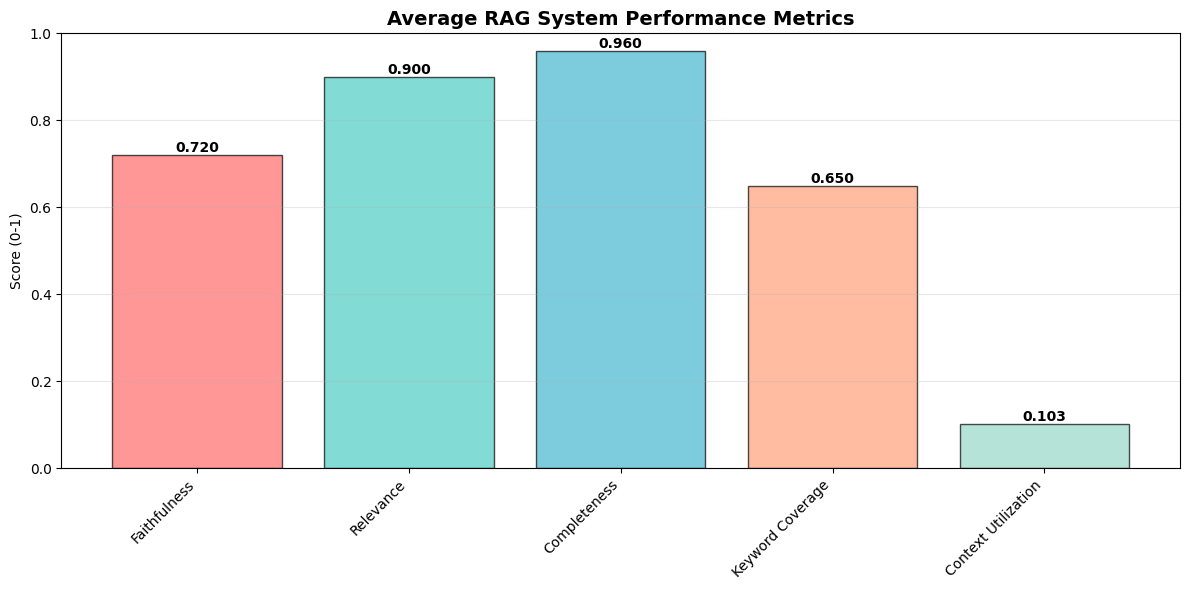

✓ Metrics comparison chart saved


In [11]:
# Visualization 1: Overall Metrics Comparison
plt.figure(figsize=(12, 6))

metrics_to_plot = ['faithfulness', 'relevance', 'completeness', 'keyword_coverage', 'context_utilization']
avg_scores = df_results[metrics_to_plot].mean()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
bars = plt.bar(range(len(avg_scores)), avg_scores.values, color=colors, alpha=0.7, edgecolor='black')
plt.xticks(range(len(avg_scores)), [m.replace('_', ' ').title() for m in metrics_to_plot], rotation=45, ha='right')
plt.ylabel('Score (0-1)')
plt.title('Average RAG System Performance Metrics', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('rag_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Metrics comparison chart saved")

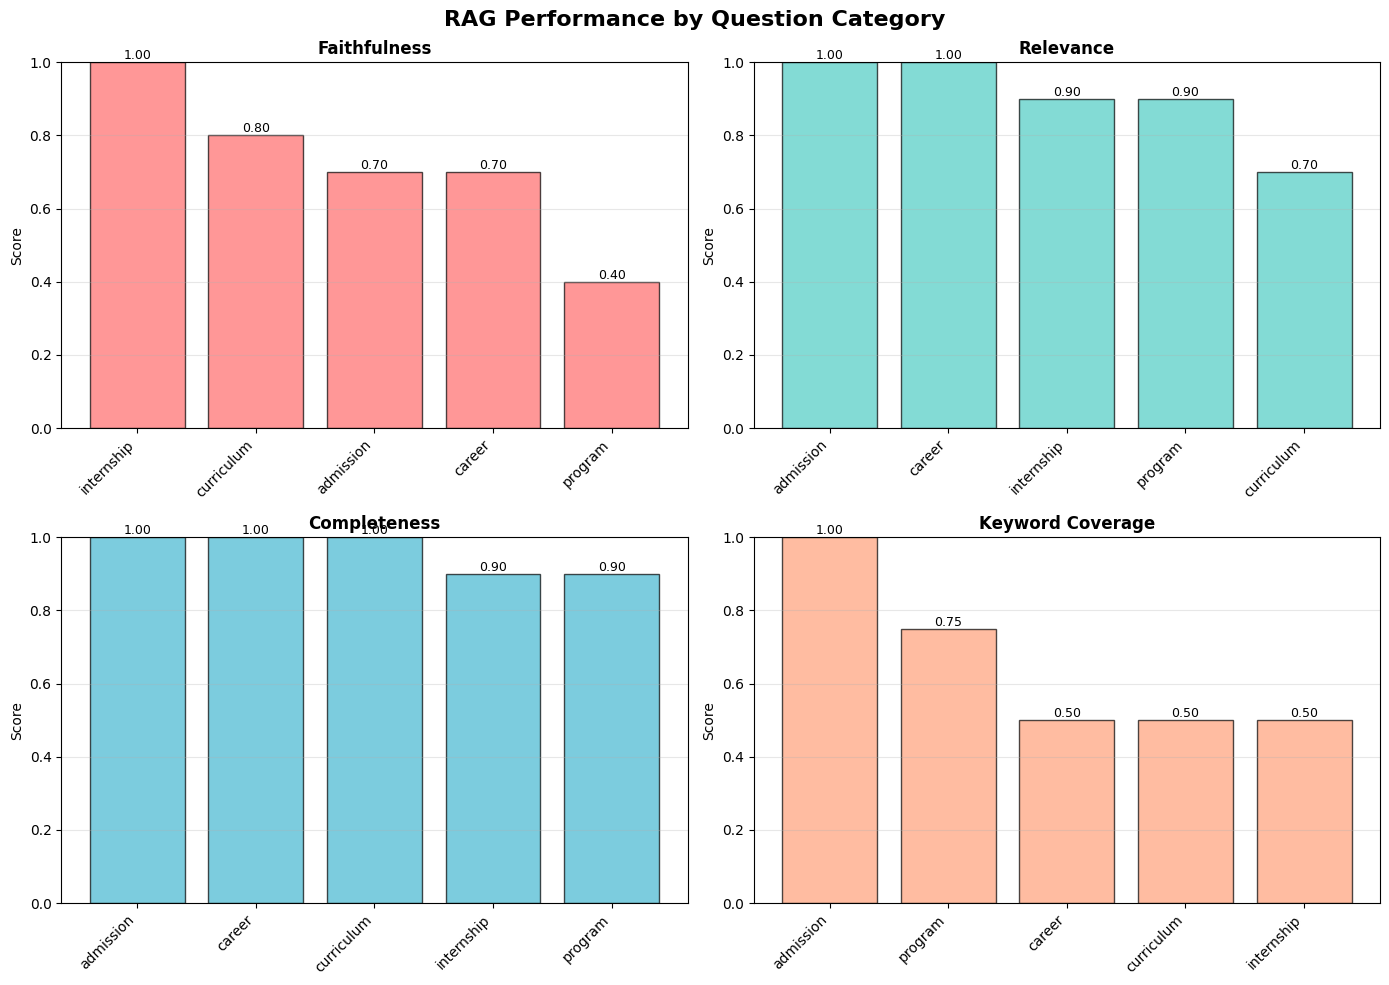

✓ Category performance chart saved


In [12]:
# Visualization 2: Performance by Category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RAG Performance by Question Category', fontsize=16, fontweight='bold')

metrics = ['faithfulness', 'relevance', 'completeness', 'keyword_coverage']
titles = ['Faithfulness', 'Relevance', 'Completeness', 'Keyword Coverage']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    category_scores = df_results.groupby('category')[metric].mean().sort_values(ascending=False)
    
    bars = ax.bar(range(len(category_scores)), category_scores.values, 
                   color=colors[idx], alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(category_scores)))
    ax.set_xticklabels(category_scores.index, rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('rag_category_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Category performance chart saved")

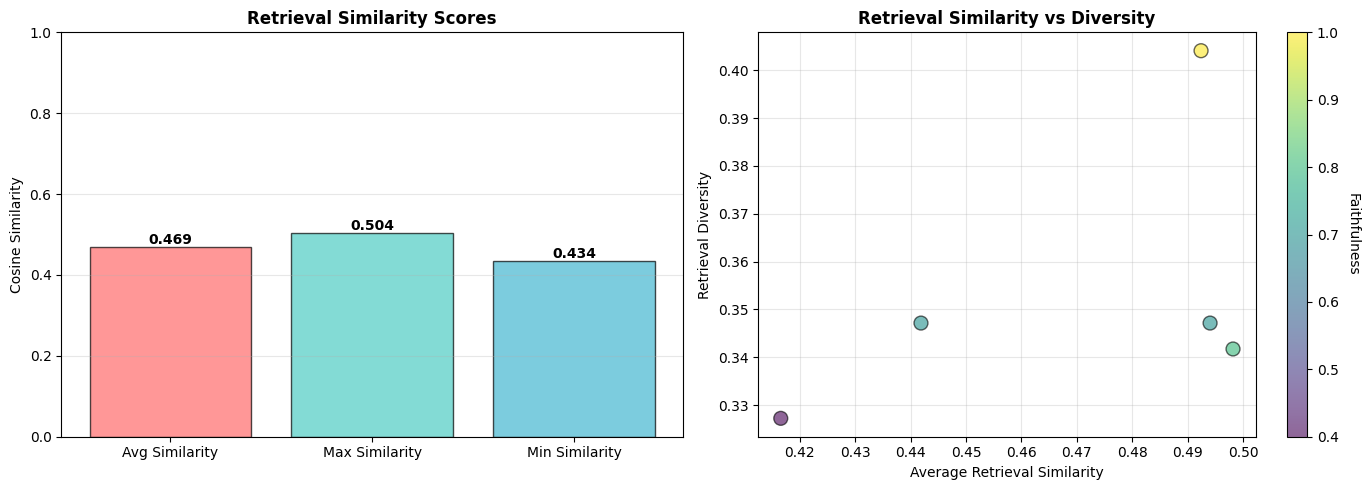

✓ Retrieval analysis chart saved


In [13]:
# Visualization 3: Retrieval Quality Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Retrieval similarity distribution
ax1 = axes[0]
retrieval_metrics = ['retrieval_avg_similarity', 'retrieval_max_similarity', 'retrieval_min_similarity']
retrieval_data = df_results[retrieval_metrics].mean()

bars1 = ax1.bar(range(len(retrieval_data)), retrieval_data.values, 
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(retrieval_data)))
ax1.set_xticklabels(['Avg Similarity', 'Max Similarity', 'Min Similarity'])
ax1.set_ylabel('Cosine Similarity')
ax1.set_title('Retrieval Similarity Scores', fontweight='bold')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# Diversity vs Similarity scatter
ax2 = axes[1]
scatter = ax2.scatter(df_results['retrieval_avg_similarity'], 
                      df_results['retrieval_diversity'],
                      c=df_results['faithfulness'], 
                      cmap='viridis', s=100, alpha=0.6, edgecolor='black')
ax2.set_xlabel('Average Retrieval Similarity')
ax2.set_ylabel('Retrieval Diversity')
ax2.set_title('Retrieval Similarity vs Diversity', fontweight='bold')
ax2.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Faithfulness', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('rag_retrieval_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Retrieval analysis chart saved")

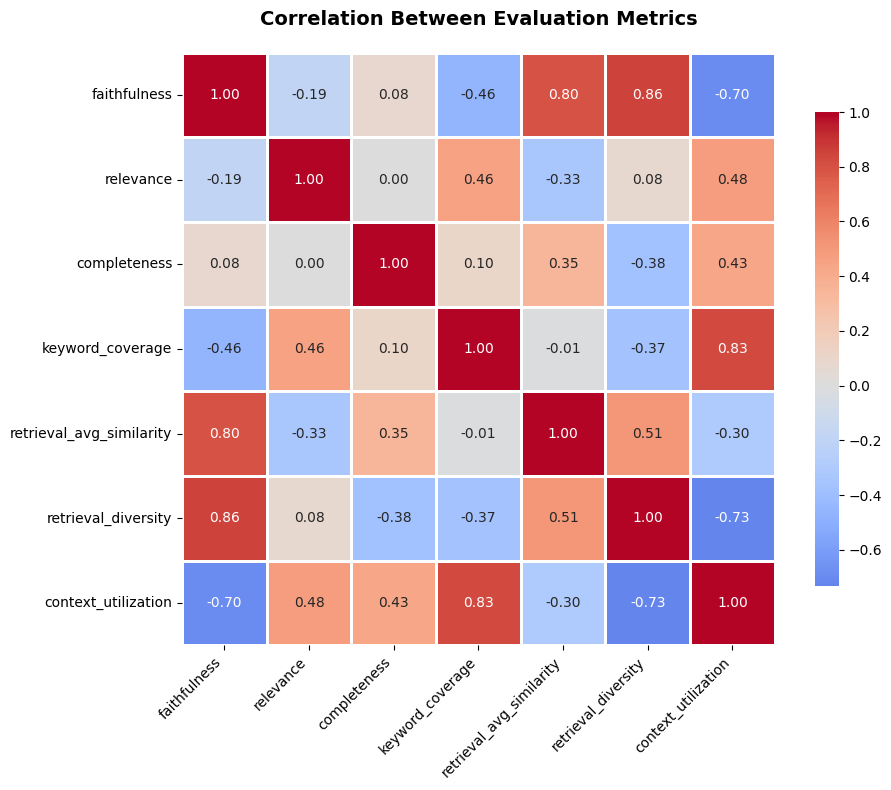

✓ Correlation heatmap saved


In [14]:
# Visualization 4: Answer Quality Heatmap
plt.figure(figsize=(10, 8))

# Create correlation matrix
quality_metrics = ['faithfulness', 'relevance', 'completeness', 'keyword_coverage', 
                   'retrieval_avg_similarity', 'retrieval_diversity', 'context_utilization']
correlation_matrix = df_results[quality_metrics].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Between Evaluation Metrics', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('rag_metrics_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap saved")

### 8. Detailed Results Report

In [15]:
# Generate detailed report
print("\n" + "=" * 80)
print("DETAILED EVALUATION REPORT")
print("=" * 80)

# Overall performance
print("\n📈 OVERALL PERFORMANCE:")
print("-" * 80)
for metric in metric_columns:
    mean_val = df_results[metric].mean()
    std_val = df_results[metric].std()
    print(f"{metric.replace('_', ' ').title():.<40} {mean_val:.3f} ± {std_val:.3f}")

# Best and worst performing queries
print("\n🏆 BEST PERFORMING QUERY:")
print("-" * 80)
best_idx = df_results['faithfulness'].idxmax()
print(f"Question: {df_results.loc[best_idx, 'question']}")
print(f"Faithfulness: {df_results.loc[best_idx, 'faithfulness']:.3f}")
print(f"Relevance: {df_results.loc[best_idx, 'relevance']:.3f}")
print(f"Completeness: {df_results.loc[best_idx, 'completeness']:.3f}")

print("\n⚠️  WEAKEST PERFORMING QUERY:")
print("-" * 80)
worst_idx = df_results['faithfulness'].idxmin()
print(f"Question: {df_results.loc[worst_idx, 'question']}")
print(f"Faithfulness: {df_results.loc[worst_idx, 'faithfulness']:.3f}")
print(f"Relevance: {df_results.loc[worst_idx, 'relevance']:.3f}")
print(f"Completeness: {df_results.loc[worst_idx, 'completeness']:.3f}")

# Category analysis
print("\n📊 PERFORMANCE BY CATEGORY:")
print("-" * 80)
for category in df_results['category'].unique():
    cat_data = df_results[df_results['category'] == category]
    print(f"\n{category.upper()}:")
    print(f"  Faithfulness: {cat_data['faithfulness'].mean():.3f}")
    print(f"  Relevance: {cat_data['relevance'].mean():.3f}")
    print(f"  Completeness: {cat_data['completeness'].mean():.3f}")
    print(f"  Keyword Coverage: {cat_data['keyword_coverage'].mean():.3f}")

# Hallucination analysis
print("\n🔍 HALLUCINATION INDICATORS:")
print("-" * 80)
print(f"Queries with uncertainty words: {df_results['hallucination_has_uncertainty'].sum()}/{len(df_results)}")
print(f"Queries with hedging phrases: {df_results['hallucination_has_hedging'].sum()}/{len(df_results)}")
print(f"Average uncertainty count: {df_results['hallucination_uncertainty_count'].mean():.2f}")

print("\n" + "=" * 80)
print("EVALUATION COMPLETE")
print("=" * 80)


DETAILED EVALUATION REPORT

📈 OVERALL PERFORMANCE:
--------------------------------------------------------------------------------
Faithfulness............................ 0.720 ± 0.217
Relevance............................... 0.900 ± 0.122
Completeness............................ 0.960 ± 0.055
Keyword Coverage........................ 0.650 ± 0.224
Retrieval Avg Similarity................ 0.469 ± 0.037
Retrieval Diversity..................... 0.353 ± 0.029
Context Utilization..................... 0.103 ± 0.042

🏆 BEST PERFORMING QUERY:
--------------------------------------------------------------------------------
Question: Are there any internship opportunities available?
Faithfulness: 1.000
Relevance: 0.900
Completeness: 0.900

⚠️  WEAKEST PERFORMING QUERY:
--------------------------------------------------------------------------------
Question: What is the difference between BEng and BSc programs?
Faithfulness: 0.400
Relevance: 0.900
Completeness: 0.900

📊 PERFORMANCE BY CATEGOR

### 9. Export Full Report

In [16]:
# Create comprehensive JSON report
report = {
    "evaluation_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_info": {
        "llm": "deepseek-r1:8b",
        "embedding": "bge-m3:567m",
        "reasoning_enabled": REASONING
    },
    "dataset_info": {
        "total_queries": len(test_dataset),
        "evaluated_queries": len(results),
        "categories": list(df_results['category'].unique())
    },
    "overall_metrics": {
        metric: {
            "mean": float(df_results[metric].mean()),
            "std": float(df_results[metric].std()),
            "min": float(df_results[metric].min()),
            "max": float(df_results[metric].max())
        }
        for metric in metric_columns
    },
    "category_performance": {
        category: {
            metric: float(df_results[df_results['category'] == category][metric].mean())
            for metric in ['faithfulness', 'relevance', 'completeness', 'keyword_coverage']
        }
        for category in df_results['category'].unique()
    },
    "detailed_results": results
}

with open('rag_evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("✓ Full evaluation report saved to 'rag_evaluation_report.json'")
print("✓ All visualizations saved as PNG files")
print("\n📁 Generated files:")
print("  - rag_evaluation_results.csv")
print("  - rag_evaluation_report.json")
print("  - rag_metrics_comparison.png")
print("  - rag_category_performance.png")
print("  - rag_retrieval_analysis.png")
print("  - rag_metrics_correlation.png")

✓ Full evaluation report saved to 'rag_evaluation_report.json'
✓ All visualizations saved as PNG files

📁 Generated files:
  - rag_evaluation_results.csv
  - rag_evaluation_report.json
  - rag_metrics_comparison.png
  - rag_category_performance.png
  - rag_retrieval_analysis.png
  - rag_metrics_correlation.png
